3.6.1
[[0 1 1 0 0]
 [0 0 0 0 0]
 [0 0 0 1 0]
 [0 0 0 0 0]
 [0 1 0 0 0]]
node attrbutes:  {1: '#1f77b4', 2: '#ff7f0e', 3: '#2ca02c', 4: '#d62728', 5: '#9467bd'}
color_map:  dict_values(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])


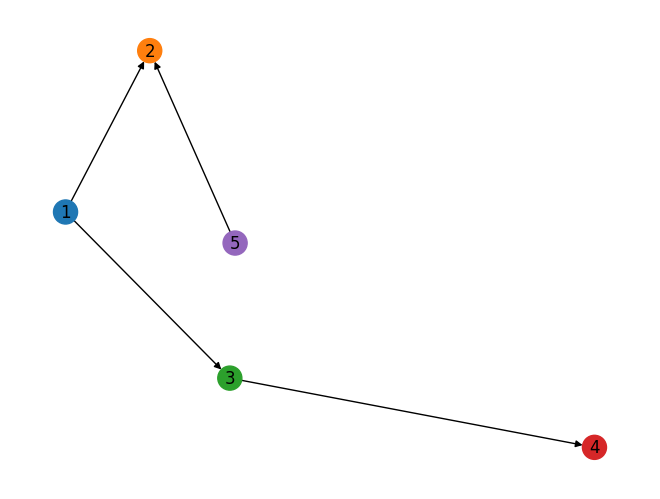

In [65]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np


dir(nx)
print(nx.__version__)

G = nx.DiGraph()

#Hex codes for colors if we draw graph
blue, orange, green, red, purple = "#1f77b4", "#ff7f0e","#2ca02c", "#d62728", "#9467bd"

G.add_nodes_from([(1, {"color": blue}),
                  (2, {"color": orange}),
                  (3, {"color": green}),
                  (4, {"color": red}),
                  (5, {"color": purple})])

G.add_edges_from([(1, 2),(1, 3),(3, 4),(5, 2)])
A = np.asarray(nx.adjacency_matrix(G).todense())
print(A)

color_map = nx.get_node_attributes(G, 'color').values()
print("node attrbutes: ",nx.get_node_attributes(G, 'color'))
print("color_map: ", color_map)
nx.draw(G, with_labels=True, node_color=color_map)

nodes:  [1, 2, 3, 4, 5]
G_rotated:  [5, 1, 3, 2, 4]
G_rotated:  [(5, 1), (5, 3), (3, 2), (4, 1)]
Adjacency matrix as tensor:  tensor([[0, 1, 1, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0]])
Rotated adjacency matrix as tensor:  tensor([[0, 1, 1, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0]])
A^2:  tensor([[0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]])
Rotated A^2:  tensor([[0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]])
A x Rotated A:  tensor([[0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]])


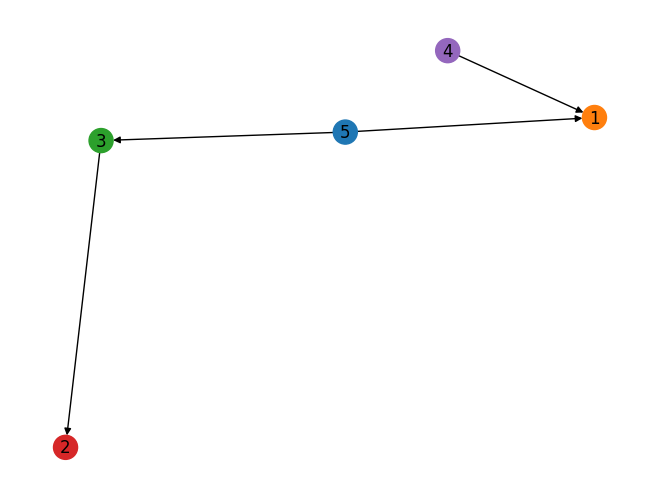

In [66]:
nodes = list(G.nodes)
print("nodes: ", nodes)

new_mapping = {1: 5, 2:1, 3:3, 4:2, 5:4}

G_rotated = nx.relabel_nodes(G, new_mapping,)
print("G_rotated: ", G_rotated.nodes)
print("G_rotated: ", G_rotated.edges)

import torch

## convert matrix to tensor
A_tensor = torch.tensor(A, dtype=torch.int64)
print("Adjacency matrix as tensor: ", A_tensor)

A_rotated = np.asarray(nx.adjacency_matrix(G_rotated).todense())
A_rotated_tensor = torch.tensor(A_rotated, dtype=torch.int64)
print("Rotated adjacency matrix as tensor: ", A_rotated_tensor)

# matrix multiplications

A_squared = torch.matmul(A_tensor, A_tensor)
print("A^2: ", A_squared)

A_rotated_squared = torch.matmul(A_rotated_tensor, A_rotated_tensor)
print("Rotated A^2: ", A_rotated_squared)

AxA_rotated = torch.matmul(A_tensor, A_rotated_tensor)
print("A x Rotated A: ", AxA_rotated)

nx.draw(G_rotated, with_labels=True, node_color=color_map)





The adjencency matrix of the original graph and the rotated graph when put through the same matrix operations should yield the same result. This is because the rotation is just a relabeling of the nodes, and does not change the underlying structure of the graph. Therefore, we should have A^2 = Rotated A^2.

In [67]:
## update edges to include weights w(i) = (i-j)^2

G = nx.DiGraph()
G.add_nodes_from([(1, {"color": blue}),
                  (2, {"color": orange}),
                  (3, {"color": green}),
                  (4, {"color": red}),
                  (5, {"color": purple})])


G.add_weighted_edges_from([(1, 2, (1-2)**2),
                           (2, 3, (2-3)**2),
                           (1, 3, (1-3)**2),
                           (3, 4, (3-4)**2),
                           (4, 5, (4-5)**2),
                           (5, 2, (5-2)**2)])
print("Edges with weights: ", G.edges(data=True))

G_rotated = nx.relabel_nodes(G, new_mapping,)
print("G_rotated edges with weights: ", G_rotated.edges(data=True))

def avg_weighted_degree(G):
    total_weight = sum(weight for _, _, weight in G.edges(data='weight'))
    num_nodes = G.number_of_nodes()
    return total_weight / num_nodes

print("Average weighted degree of original graph: ", avg_weighted_degree(G))
G_rotated.add_weighted_edges_from([(1, 2, (1-2)**2),
                                  (2, 3, (2-3)**2),
                                  (1, 3, (1-3)**2),
                                  (3, 4, (3-4)**2),
                                  (4, 5, (4-5)**2),
                                  (5, 2, (5-2)**2)])
print("Average weighted degree of rotated graph: ", avg_weighted_degree(G_rotated))


Edges with weights:  [(1, 2, {'weight': 1}), (1, 3, {'weight': 4}), (2, 3, {'weight': 1}), (3, 4, {'weight': 1}), (4, 5, {'weight': 1}), (5, 2, {'weight': 9})]
G_rotated edges with weights:  [(5, 1, {'weight': 1}), (5, 3, {'weight': 4}), (1, 3, {'weight': 1}), (3, 2, {'weight': 1}), (2, 4, {'weight': 1}), (4, 1, {'weight': 9})]
Average weighted degree of original graph:  3.4
Average weighted degree of rotated graph:  6.6


The f() is permutation equvarient since the avarage weight of the rotated graph is not equal to the average weight of the original graph.

In [68]:
G0,G1,G2,G3,G4,G5 = nx.Graph(), nx.Graph(), nx.Graph(), nx.Graph(), nx.Graph(), nx.Graph()

#Hex codes for colors if we draw graph
carbon, oxygen, nitrogen = "#1f77b4", "#ff7f0e","#2ca02c"

G0.add_nodes_from([(1, {"color": carbon}),
                  (2, {"color": oxygen}),
                  (3, {"color": carbon}),
                  (4, {"color": nitrogen})])

G0.add_edges_from([(1, 2),(2, 3),(1, 3),(3, 4)])

G1.add_nodes_from([(1, {"color": carbon}),
                  (2, {"color": oxygen}),
                  (3, {"color": carbon}),
                  (4, {"color": nitrogen})])
G1.add_edges_from([(1, 2),(2, 3),(1, 3),(3, 4)])

G2.add_nodes_from([(1, {"color": carbon}),
                  (2, {"color": oxygen}),
                  (3, {"color": carbon}),
                  (4, {"color": nitrogen}),
                  (5, {"color": carbon})])
G2.add_edges_from([(1, 2),(2, 3),(1, 3),(3, 4),(4, 5)])

G3.add_nodes_from([(1, {"color": carbon}),
                  (2, {"color": oxygen}),
                  (3, {"color": carbon}),
                  (4, {"color": nitrogen}),
                  (5, {"color": carbon})])
G3.add_edges_from([(1, 2),(2, 3),(1, 3),(3, 4),(4, 5)])

G4.add_nodes_from([(1, {"color": carbon}),
                  (2, {"color": oxygen}),
                  (3, {"color": carbon}),
                  (4, {"color": nitrogen}),
                  (5, {"color": carbon}),
                  (6, {"color": oxygen})])
G4.add_edges_from([(1, 2),(2, 3),(1, 3),(3, 4),(4, 5),(5, 6)])


#adjacency matrix of G0
A1 = np.asarray(nx.adjacency_matrix(G0).todense())
print(A1)

import pandas as pd
def one_hot_encode(G):
    node_attrs = {node: G.nodes[node]['color'] for node in G.nodes}
    df = pd.Series(node_attrs)
    one_hot_matrix = pd.get_dummies(df).values
    return one_hot_matrix['type'(one_hot_encode(G0))]

one_hot_G0 = one_hot_encode(G0)
print("One-hot encoding of G0: ", one_hot_G0)

[[0 1 1 0]
 [1 0 1 0]
 [1 1 0 1]
 [0 0 1 0]]


<>:51: SyntaxWarning: 'str' object is not callable; perhaps you missed a comma?
<>:51: SyntaxWarning: 'str' object is not callable; perhaps you missed a comma?
/var/folders/hr/56tdh60x4712fhss1_h0nrsc0000gn/T/ipykernel_15408/3757946612.py:51: SyntaxWarning: 'str' object is not callable; perhaps you missed a comma?
  return one_hot_matrix['type'(one_hot_encode(G0))]


RecursionError: maximum recursion depth exceeded in comparison